In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 15:20:18.677173


# Gaussian fit

## Next steps --> need to map the barcodes into neuron only fraction

GMM on a subset of the data as analysis strategy for separating signal and noise

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150
#sc.set_figure_params(scanpy=True)

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

# have to use the version of the dataset that has the transgenes to draw positive and negative signal

#bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheld


In [6]:
transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

In [7]:
adata.X[:5, :5].toarray()

array([[ 6.368892,  9.411781,  0.      ,  8.932259,  0.      ],
       [ 5.934714,  9.823938,  0.      ,  9.067674,  0.      ],
       [ 0.      , 10.099765,  0.      ,  8.800591,  0.      ],
       [ 0.      ,  7.36252 ,  0.      ,  0.      ,  0.      ],
       [ 0.      , 10.807536,  0.      ,  8.25573 ,  0.      ]],
      dtype=float32)

In [8]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

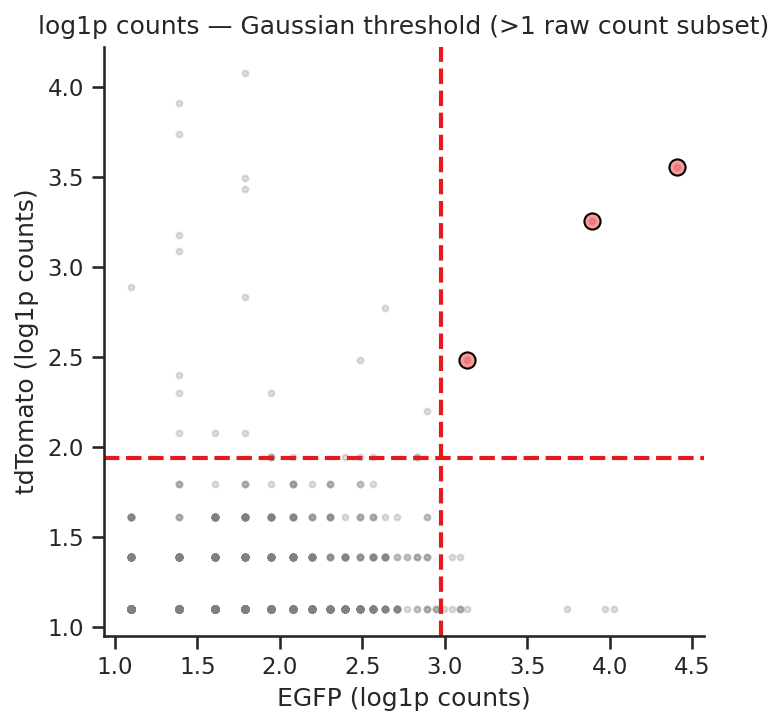

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture  # used only for 1-comp but we remove "posterior" usage

sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# Filter: only cells with >1 raw count in BOTH genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(counts) --------
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit a simple one-component Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# Dual-high
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)

dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# -------- Plot --------
plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p counts — Gaussian threshold (>1 raw count subset)")

sns.despine()
plt.tight_layout()
plt.show()

In [10]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
aapmhgin-1-0
aefmnmje-1-2
mklknhcg-1-2

Total: 3 barcodes printed.


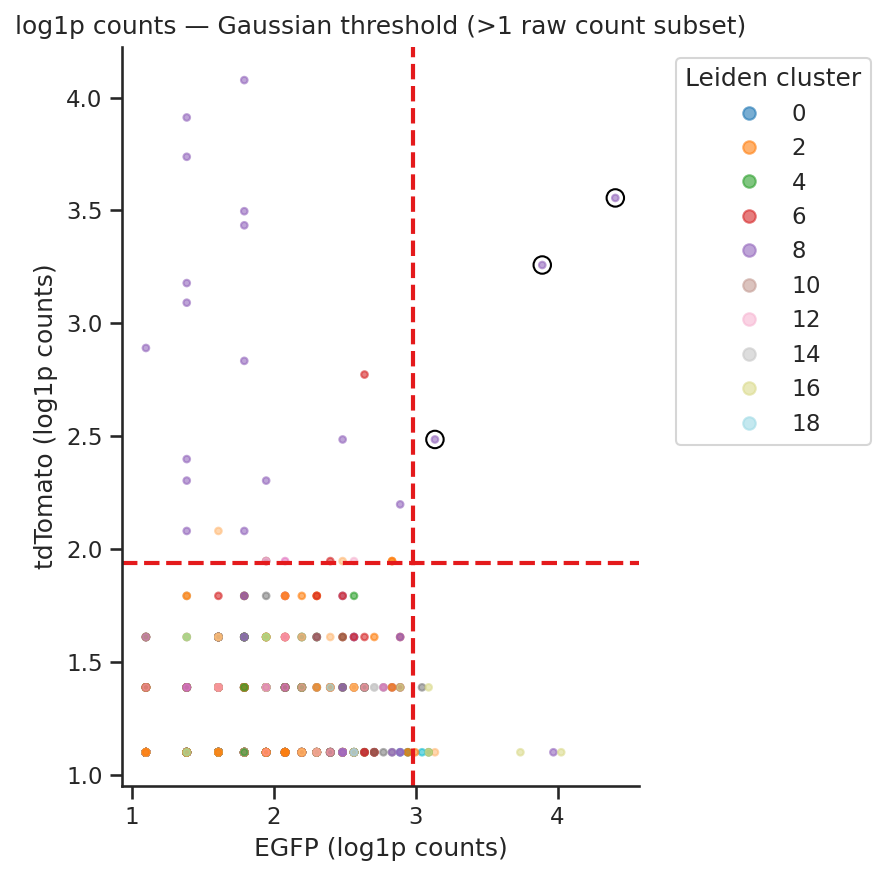

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# Filter: only cells with >1 raw count in BOTH genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(counts) --------
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Gaussian parameters
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 SD
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# Dual-high
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# ---------- FIXED HERE ----------
# Color by Leiden cluster (must be integers)
cluster_colors = adata.obs['leiden_scVI_1'][bg_filter].astype(int)
# --------------------------------

# -------- Plot --------
plt.figure(figsize=(6,6), dpi=150)
ax = plt.gca()

# all cells colored by cluster
scatter = ax.scatter(
    x_egfp_log, x_td_log,
    s=10,
    c=cluster_colors,
    cmap="tab20",
    alpha=0.6
)

# dual-positive highlighted with black outline
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=70,
    facecolors='none',
    edgecolors='black',
    linewidths=1.0,
    label="Dual-high"
)

# Threshold lines
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p counts — Gaussian threshold (>1 raw count subset)")

# Legend for clusters
handles, labels = scatter.legend_elements(prop="colors")
plt.legend(handles, labels, title="Leiden cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

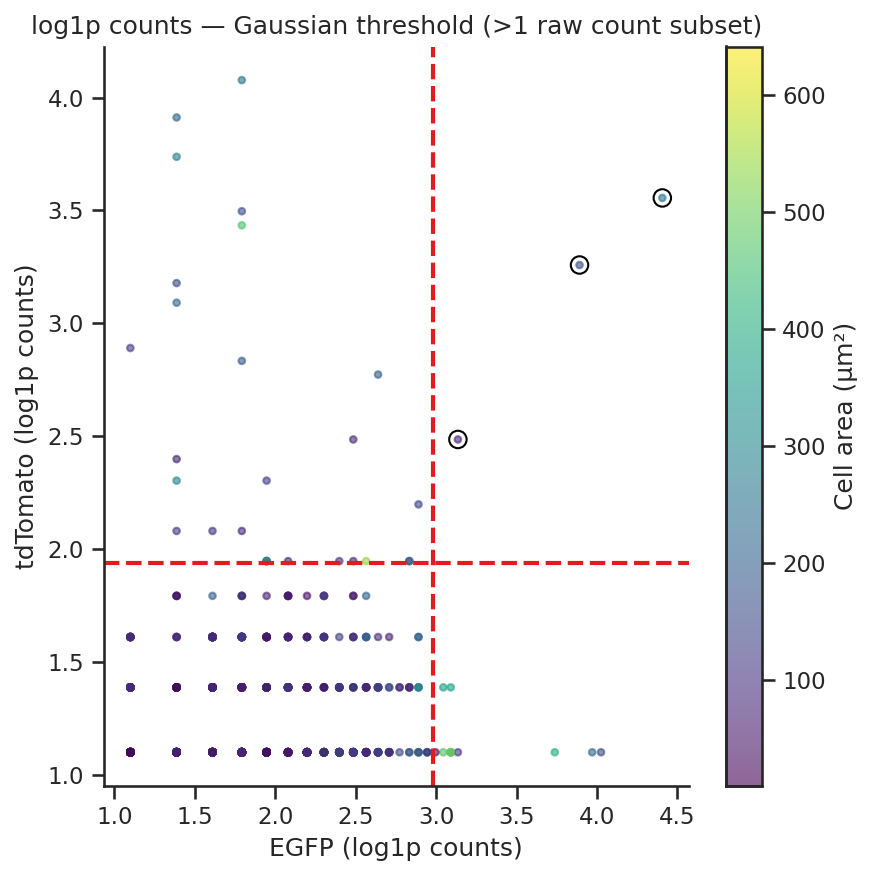

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# Filter: only cells with >1 raw count in BOTH genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(counts) --------
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Gaussian parameters
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 SD
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# Dual-high
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# ---------- NEW: continuous coloring by cell area ----------
cell_area_colors = adata.obs['cell_area'][bg_filter].astype(float)
# ----------------------------------------------------------

# -------- Plot --------
plt.figure(figsize=(6,6), dpi=150)
ax = plt.gca()

# all cells colored by cell area
scatter = ax.scatter(
    x_egfp_log, x_td_log,
    s=10,
    c=cell_area_colors,
    cmap="viridis",
    alpha=0.6
)

# dual-positive highlighted with black outline
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=70,
    facecolors='none',
    edgecolors='black',
    linewidths=1.0,
    label="Dual-high"
)

# Threshold lines
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p counts — Gaussian threshold (>1 raw count subset)")

# Colorbar for cell area
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cell area (µm²)")

sns.despine()
plt.tight_layout()
plt.show()

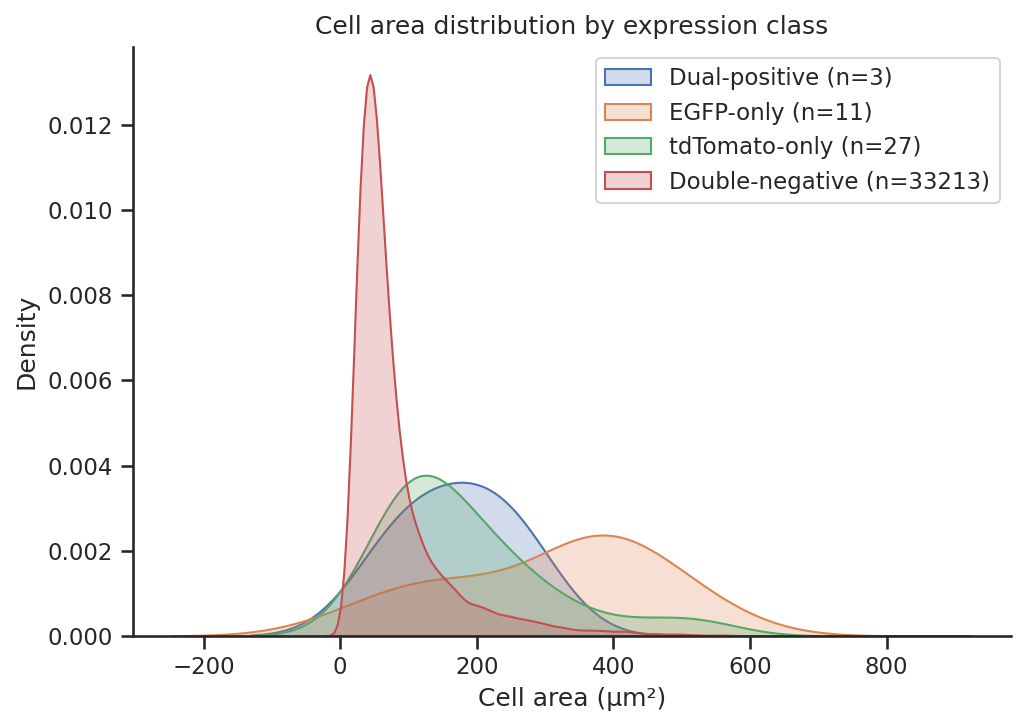

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="ticks")

# Extract area
cell_area = adata.obs['cell_area'].values

# Expression category masks
egfp_hi = adata.obs['EGFP_Seq1_hi'].values
td_hi   = adata.obs['tdTomato_Seq2_hi'].values
dual_hi = adata.obs['EGFP_tdTomato_dual_hi'].values

# Single positive masks
egfp_only = egfp_hi & (~td_hi)
td_only   = td_hi & (~egfp_hi)
neg_neg   = (~egfp_hi) & (~td_hi)

# Prepare data
data = {
    "Dual-positive": cell_area[dual_hi],
    "EGFP-only": cell_area[egfp_only],
    "tdTomato-only": cell_area[td_only],
    "Double-negative": cell_area[neg_neg],   # optional, remove if you want
}

# Plot
plt.figure(figsize=(7,5), dpi=150)

for label, vals in data.items():
    if len(vals) > 0:
        sns.kdeplot(vals, fill=True, alpha=0.25, label=f"{label} (n={len(vals)})")

plt.xlabel("Cell area (µm²)")
plt.ylabel("Density")
plt.title("Cell area distribution by expression class")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()